# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [2]:
fs = 1000
T = 1
t = np.arange(0, T, 1 / fs)

print("Частота дискретизации:", fs, "Гц")
print("Длительность сигнала:", T, "с")
print("Количество отсчётов:", len(t))
print("Период дискретизации:", 1 / fs, "с")

Частота дискретизации: 1000 Гц
Длительность сигнала: 1 с
Количество отсчётов: 1000
Период дискретизации: 0.001 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен 0.001 с. Он обратно пропорционален частоте дискретизации: чем выше частота дискретизации, тем меньше период.

### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

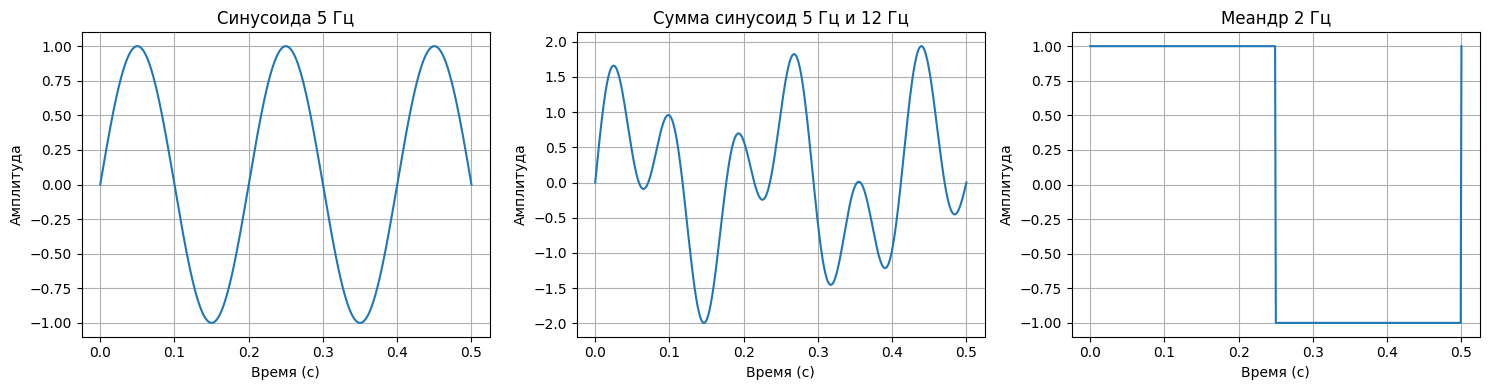

In [3]:
# Синусоида 5 Гц
f1 = 5
sin5 = np.sin(2 * np.pi * f1 * t)

# Сумма синусоид 5 и 12 Гц
f2 = 12
sum_sin = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# Меандр 2 Гц
# meander = []
f_square = 2
square_wave = signal.square(2 * np.pi * f_square * t)

# Визуализация
mask = t <= 0.5

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(t[mask], sin5[mask])
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t[mask], sum_sin[mask])
plt.title('Сумма синусоид 5 Гц и 12 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t[mask], square_wave[mask])
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы синусоид изменяется, если одну из них сдвинуть по фазе на 90° или 180°, и не изменяется, если сдвинуть на 360°. Это происходит, поскольку синусоидальные функции являются периодическими. 
Их период по фазе равен $2\pi$, поэтому сдвиг на 360° не изменяет сигнал. При сдвиге на 90° или 180° изменяется взаимное положение синусоид, из-за чего меняется форма их суммы.

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

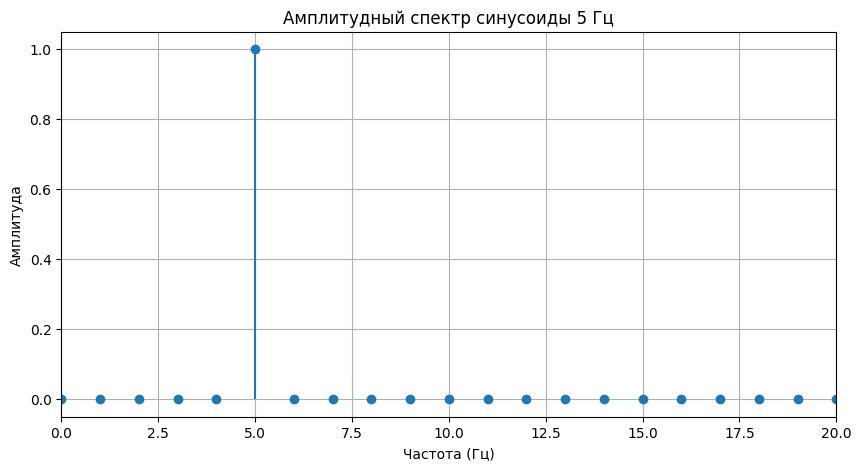

Частота максимального пика: 5.0 Гц
Амплитуда пика: 1.0


In [4]:
# БПФ синусоиды 5 Гц
X = np.fft.fft(sin5)
freq = np.fft.fftfreq(len(t), d=1 / fs)

# Берём только положительные частоты
half = len(t)//2
X_mag = 2 * np.abs(X[:half]) / len(t)  # не забываем про нормировку амплитуды
freq_pos = freq[:half] # только положительные частоты

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

peak_idx = np.argmax(X_mag)
print("Частота максимального пика:", freq_pos[peak_idx], "Гц")
print("Амплитуда пика:", X_mag[peak_idx])

**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку в сигнале содержится только одна частота — **5 Гц**. Его теоретическая амплитуда должна быть равна 1. Она совпадает с полученной, поскольку сигнал состоит из одной синусоидальной гармоники с амплитудой 1, а при вычислении БПФ была выполнена нормировка спектра. Благодаря этой нормировке амплитуда спектрального пика соответствует реальной амплитуде исходного сигнала.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

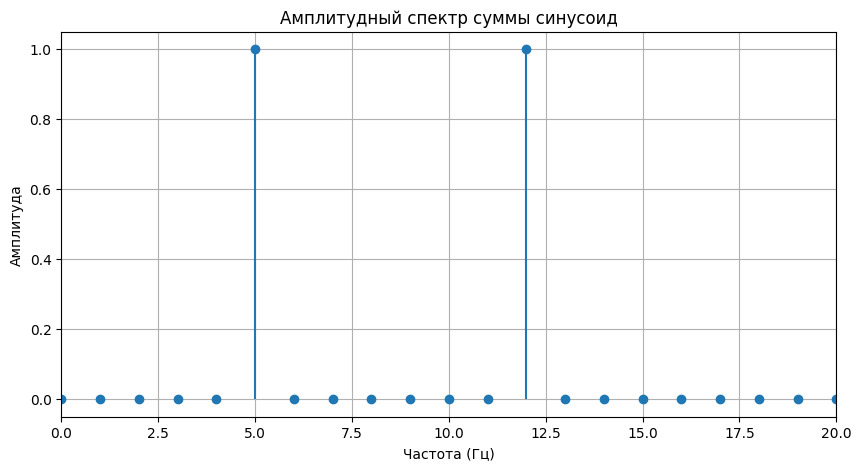

Амплитуда на 5 Гц: 1.0000000000000004
Амплитуда на 12 Гц: 0.9999999999999994


In [5]:
X_sum = np.fft.fft(sum_sin)
X_sum_mag = 2 * np.abs(X_sum[:half]) / len(t)

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_sum_mag, basefmt=" ")
plt.title('Амплитудный спектр суммы синусоид')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

idx5 = np.argmin(np.abs(freq_pos - 5))
idx12 = np.argmin(np.abs(freq_pos - 12))

print("Амплитуда на 5 Гц:", X_sum_mag[idx5])
print("Амплитуда на 12 Гц:", X_sum_mag[idx12])

**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, то амплитудный спектр не изменится.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

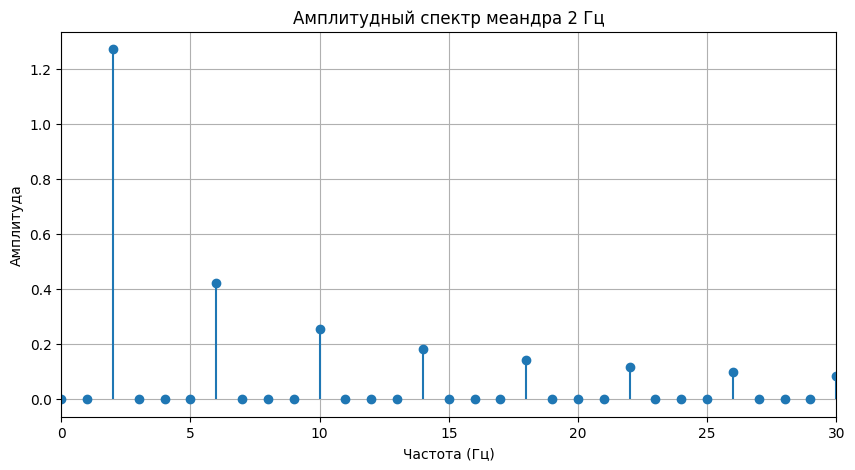

1-я гармоника (2 Гц): амплитуда 1.273
3-я гармоника (6 Гц): амплитуда 0.424
5-я гармоника (10 Гц): амплитуда 0.255
7-я гармоника (14 Гц): амплитуда 0.182


In [6]:
X_square = np.fft.fft(square_wave)
X_square_mag = 2 * np.abs(X_square[:half]) / len(t)

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_square_mag, basefmt=" ")
plt.title('Амплитудный спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()

harmonics = [(1, 2), (3, 6), (5, 10), (7, 14)]

for n, freq_harm in harmonics:
    idx = np.argmin(np.abs(freq_pos - freq_harm))
    print(f"{n}-я гармоника ({freq_harm} Гц): амплитуда {X_square_mag[idx]:.3f}")


**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку симметричный меандр обладает такой формой, при которой чётные гармоники взаимно компенсируются, и в разложении Фурье остаются только нечётные составляющие.

Вычислим теоретические амплитуды нескольких первых гармоник: 
1-я гармоника (2 Гц): амплитуда 1.273
3-я гармоника (6 Гц): амплитуда 0.424
5-я гармоника (10 Гц): амплитуда 0.255
7-я гармоника (14 Гц): амплитуда 0.182

При численном вычислении Фурье-преобразования получились следующие значения амплитуд гармоник: для частот 2 Гц, 6 Гц, 10 Гц и 14 Гц амплитуды близки соответственно к 1.273, 0.424, 0.255 и 0.182.

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

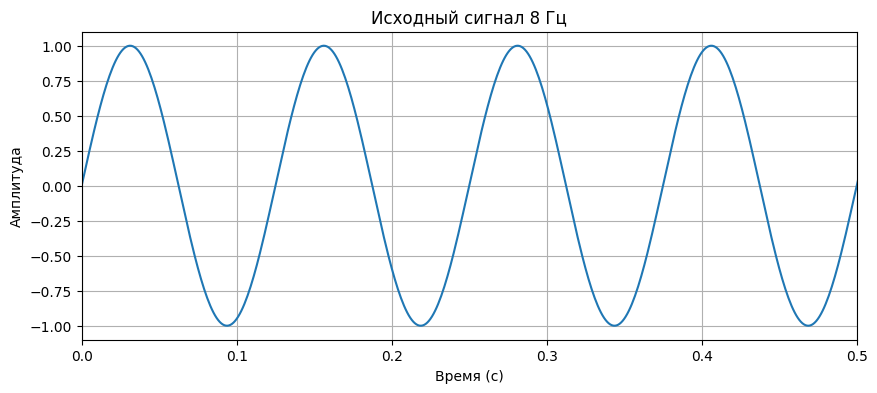

In [7]:
# «Аналоговый» сигнал с высокой частотой дискретизации
f_signal = 8
t_cont = np.arange(0, 1, 1 / 1000)
x_cont = np.sin(2 * np.pi * f_signal * t_cont)

plt.figure(figsize=(10, 4))
plt.plot(t_cont, x_cont)
plt.title('Исходный сигнал 8 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.xlim(0, 0.5)
plt.grid(True)
plt.show()

Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

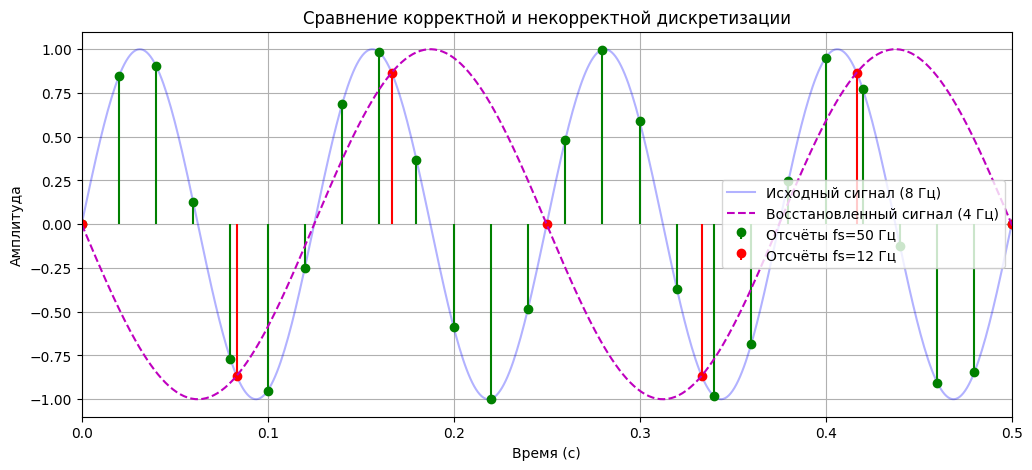

In [10]:
# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

# Отсчёты при корректной дискретизации
t1 = np.arange(0, 1, 1 / fs1)
samples1 = np.sin(2 * np.pi * f_signal * t1)

# Отсчёты при некорректной дискретизации (алиасинг)
t2 = np.arange(0, 1, 1 / fs2)
samples2 = np.sin(2 * np.pi * f_signal * t2)

# "Воспринимаемая" частота с учетом знака
f_alias_signed = f_signal - round(f_signal / fs2) * fs2

# Восстановленный сигнал, проходящий через красные маркеры
x_alias = np.sin(2 * np.pi * f_alias_signed * t_cont)

plt.figure(figsize=(12, 5))
plt.plot(t_cont, x_cont, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.stem(t1, samples1, linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')
plt.stem(t2, samples2, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')
plt.plot(t_cont, x_alias, 'm--', label=f'Восстановленный сигнал ({abs(f_alias_signed):.0f} Гц)')

plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

В сигнале при $f_{s2}=12$ Гц кажется, что присутствует частота **4 Гц**. Она совпадает с теоретической: $f_{alias}$ = |f - k * f_s| = |8 - 1 * 12| = 4 при k=1

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [9]:
def plot_aliasing(f_signal, f_sampling):
    t_cont = np.linspace(0, 1, 2000)
    x_cont = np.sin(2 * np.pi * f_signal * t_cont)

    t_disc = np.arange(0, 1, 1 / f_sampling)
    x_disc = np.sin(2 * np.pi * f_signal * t_disc)

    f_alias = abs(f_signal - round(f_signal / f_sampling) * f_sampling)
    if f_alias > f_sampling / 2:
        f_alias = abs(f_sampling - f_alias)

    x_alias = np.sin(2 * np.pi * f_alias * t_cont)

    plt.figure(figsize=(12, 4))
    plt.plot(t_cont, x_cont, label='Исходный сигнал')
    plt.stem(t_disc, x_disc, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
    plt.plot(t_cont, x_alias, '--', label=f'Видимый alias: {f_alias:.2f} Гц')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Частота сигнала = {f_signal} Гц, fs = {f_sampling} Гц')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.show()

_ = widgets.interact(
    plot_aliasing,
    f_signal=widgets.IntSlider(value=8, min=1, max=30, step=1, description='f сигнала'),
    f_sampling=widgets.IntSlider(value=20, min=5, max=60, step=1, description='fs')
)

interactive(children=(IntSlider(value=8, description='f сигнала', max=30, min=1), IntSlider(value=20, descript…

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда частота сигнала превышает половину частоты дискретизации, то есть когда нарушается критерий Найквиста.

Когда частота сигнала в точности равна половине частоты дискретизации, то это соответствует частоте Найквиста, и отсчёты сигнала попадают в одинаковые точки периода. В результате восстановление сигнала становится неоднозначным и возможны искажения.